# Lab Day 2: Backbone, công thức huấn luyện và suy luận trên DeepWeeds

**Nguyễn Sơn Giang · 2A202602747**

Notebook tổng hợp của bài nộp. Các thí nghiệm được chạy trên cụm GPU SLURM bằng các script trong `code/`, mỗi lần chạy lưu ra `runs/<exp_id>/seed<k>/`. Notebook này:
1. Tải và kiểm tra dữ liệu (Bước 0).
2. Đọc **kết quả thật** đã lưu để hiển thị bảng và biểu đồ của từng bước.
3. Chạy `eval.py score` và `eval.py grade` trên `predictions/`.

Đặt `RUN_TRAINING = True` để train lại một thí nghiệm mẫu bằng đúng hàm `train.run(Config)` mà mọi thí nghiệm đã dùng.

**Quy tắc:** mọi lựa chọn đều dựa trên **val**; test chỉ chạy **một lần mỗi seed** trong `final_predict.py`. Báo cáo đầy đủ: `../report.md`.

## 0. Cài đặt môi trường

In [1]:
import sys, os, json, platform, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules or "KAGGLE_KERNEL_RUN_TYPE" in os.environ
if IN_COLAB:   # Colab/Kaggle: cài đúng phiên bản (xem requirements.txt)
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "timm==1.0.15", "openpyxl"], check=True)

CODE = Path.cwd()                      # thư mục code/ của bài nộp
SUB = CODE.parent                      # submissions/<mssv>_<ten>/
REPO = CODE.parents[2]                 # gốc repo bài lab (chứa eval.py và data/)
assert (REPO / "eval.py").exists(), f"Không thấy eval.py ở {REPO}: chạy notebook từ thư mục code/"
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(CODE))

import numpy as np, pandas as pd, torch, timm
from IPython.display import Image, Markdown, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 60)

RUN_TRAINING = False                   # True: train lại một thí nghiệm mẫu (cần GPU)
print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU (chỉ đọc kết quả)")

/vol/biomedic3/gn425/envs/labinaction/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python 3.10.19 | torch 2.6.0+cu124 | timm 1.0.15
GPU: KHÔNG CÓ GPU (chỉ đọc kết quả)


### Tải dữ liệu
Ảnh lấy từ Zenodo (có kiểm tra MD5); nhãn và các file chia fold lấy từ GitHub của tác giả. Ô này chỉ tải khi chưa có dữ liệu.

In [2]:
import hashlib, urllib.request, zipfile

DATA = REPO / "data"
IMAGES_DIR, LABELS_DIR = DATA / "images", DATA / "labels"
LABELS_DIR.mkdir(parents=True, exist_ok=True)
if not IMAGES_DIR.exists():
    zp = DATA / "images.zip"
    if not zp.exists():
        urllib.request.urlretrieve("https://zenodo.org/records/7939060/files/images.zip?download=1", zp)
    h = hashlib.md5()
    with open(zp, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"
    zipfile.ZipFile(zp).extractall(IMAGES_DIR)
BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    if not (LABELS_DIR / f"{name}.csv").exists():
        urllib.request.urlretrieve(f"{BASE}/{name}.csv", LABELS_DIR / f"{name}.csv")
print(len(list(IMAGES_DIR.glob("*.jpg"))), "ảnh;", sorted(p.name for p in LABELS_DIR.glob("*subset0.csv")))

17509 ảnh; ['test_subset0.csv', 'train_subset0.csv', 'val_subset0.csv']


## Bước 0: EDA và kiểm tra pipeline
Kiểm tra chia dữ liệu theo README mục 2.1: số ảnh mỗi tập và mỗi lớp, giao giữa các tập rỗng, hợp đủ 17.509 ảnh, mọi file đều có trên đĩa. Hàm cũng đối chiếu nhãn với `labels.csv`.

In [3]:
import dataset as D
train_df, val_df, test_df = D.load_split(LABELS_DIR, fold=0)
rep = D.check_split(train_df, val_df, test_df, IMAGES_DIR, labels_csv=LABELS_DIR / "labels.csv")

CẢNH BÁO: 1 ảnh có Label khác labels.csv (giữ nhãn của fold): [{'Filename': '20170714-110407-3.jpg', 'Label': 0, 'Label_ref': 1}]
Số ảnh: {'train': 10501, 'val': 3501, 'test': 3507}  (tỉ lệ {'train': 0.5997, 'val': 0.2, 'test': 0.2003}), hợp = 17509
Giao theo Filename: {'train&val': 0, 'train&test': 0, 'val&test': 0}; file thiếu trên đĩa: 0; số ảnh nhãn lệch labels.csv: 1
                train   val  test  total
Chinee Apple      675   225   226   1126
Lantana           637   213   213   1063
Parkinsonia       618   206   207   1031
Parthenium        613   204   205   1022
Prickly Acacia    637   212   213   1062
Rubber Vine       605   202   202   1009
Siam Weed         644   215   215   1074
Snake Weed        609   203   204   1016
Negatives        5463  1821  1822   9106
Tỉ lệ lớp lớn nhất / nhỏ nhất: 9.02


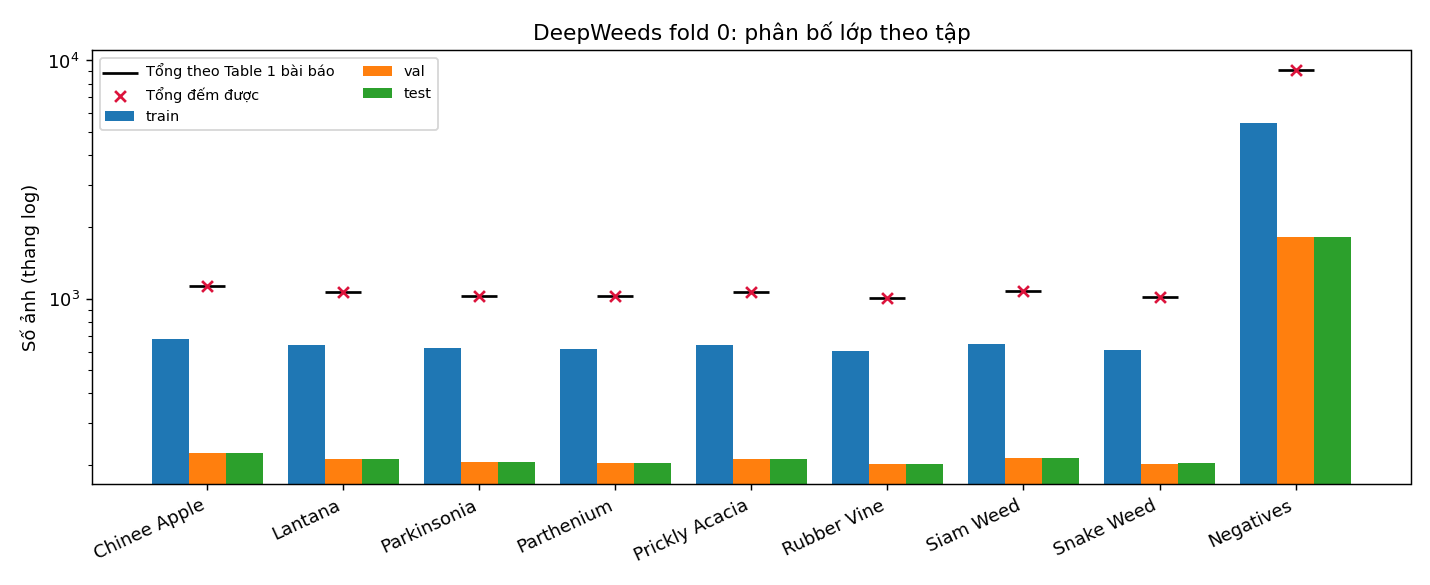

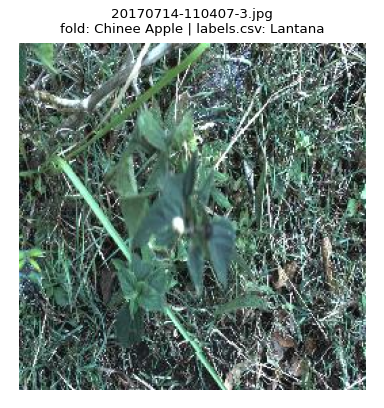

In [4]:
display(Image(SUB / "figures" / "eda_class_distribution.png", width=850))
display(Image(SUB / "figures" / "eda_label_mismatch.png", width=300))

**Kiểm tra pipeline** (`sanity.py`, slide trang 59):
- loss ban đầu ≈ ln 9;
- overfit được 16 ảnh;
- `eval()` cho logit gần như giống hệt dù chạy batch 1 hay batch 64;
- vẽ ảnh sau augmentation.

Ngoài ra có 22 unit test (`test_code.py`), chạy được không cần GPU.

ln 9 = 2.1972


,loss ban đầu
resnet50,2.2308
resnext50_32x4d,2.2165
convnext_tiny.fb_in1k,2.1936
deit_small_patch16_224,2.2134
swin_tiny_patch4_window7_224,2.2401
efficientnet_b0,2.2427
mobilenetv3_large_100,2.2564


overfit 16 ảnh: {'n_images': 16, 'steps': 150, 'loss_first': 2.19579, 'loss_last': 7.8e-05, 'acc_eval_mode': 1.0}
eval(): |logit batch 64 - batch 1| max = 1.4e-04


OK


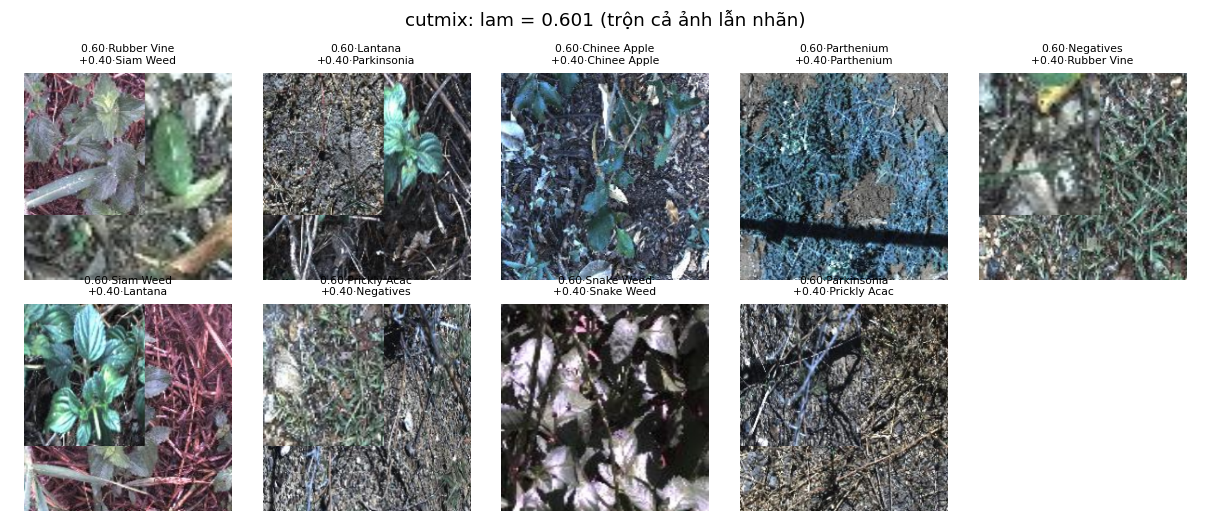

In [5]:
s = json.loads((SUB / "sanity.json").read_text())
print(f"ln 9 = {s['ln9']:.4f}")
display(pd.Series(s["initial_loss"], name="loss ban đầu").round(4).to_frame())
print("overfit 16 ảnh:", {k: round(v, 6) if isinstance(v, float) else v for k, v in s["overfit"].items()})
print("eval(): |logit batch 64 - batch 1| max =", f"{s['eval_batch_invariance_maxabs']:.1e}")
r = subprocess.run([sys.executable, "-m", "unittest", "test_code"], capture_output=True, text=True,
                   env={**os.environ, "CUDA_VISIBLE_DEVICES": ""})
print(r.stderr.strip().splitlines()[-1])
display(Image(SUB / "figures" / "sanity_cutmix.png", width=850))

## Bước 1: So sánh backbone (≥ 5)
Mọi thí nghiệm đi qua `train.run(Config)`. Ô dưới chạy lại thí nghiệm mẫu nếu bật `RUN_TRAINING`; còn lại đọc kết quả đã lưu.

Tiền xử lý val ban đầu ("Resize 256 + CenterCrop 224") **không nội suy** ảnh gốc 256×256, trong khi ảnh train luôn bị nội suy. Lỗi này làm sai thứ hạng của các mạng BatchNorm; xem báo cáo mục 3.1. Bảng dưới gồm B01–B07 (nền gốc) và B11–B17 (nền đã sửa).

,exp_id,backbone,weight_tag,params_M,gmacs,n_seeds,macro_f1_val_mean,macro_f1_val_std,top1_val_mean,train_s_per_epoch_mean,latency_b1_p50_ms_mean,gpu
0,B01,resnet50,resnet50.a1_in1k,23.5265,4.0872,3,0.8027,0.0041,0.8567,12.0723,4.7691,NVIDIA GeForce RTX 3090
1,B02,resnext50_32x4d,resnext50_32x4d.a1h_in1k,22.9983,4.2285,1,0.7126,NaN,0.7815,13.7331,4.5786,NVIDIA GeForce RTX 3090
2,B03,convnext_tiny.fb_in1k,convnext_tiny.fb_in1k,27.8270,4.4548,3,0.9526,0.0012,0.9645,16.0424,4.2732,NVIDIA GeForce RTX 3090
3,B04,deit_small_patch16_224,deit_small_patch16_224.fb_in1k,21.6691,4.2408,1,0.9490,NaN,0.9634,11.8906,3.5273,NVIDIA GeForce RTX 3090
4,B05,swin_tiny_patch4_window7_224,swin_tiny_patch4_window7_224.ms_in1k,27.5263,4.4898,1,0.9498,NaN,0.9614,20.4018,7.5605,NVIDIA GeForce RTX 3090
5,B06,efficientnet_b0,efficientnet_b0.ra_in1k,4.0191,0.3845,1,0.8321,NaN,0.8712,10.6123,5.6264,NVIDIA GeForce RTX 3090
6,B07,mobilenetv3_large_100,mobilenetv3_large_100.ra_in1k,4.2136,0.2153,3,0.7751,0.0123,0.8326,10.0254,4.9800,NVIDIA GeForce RTX 3090
7,B11,resnet50,resnet50.a1_in1k,23.5265,4.0872,3,0.8463,0.0071,0.8834,11.8193,4.9256,NVIDIA GeForce RTX 3090
8,B12,resnext50_32x4d,resnext50_32x4d.a1h_in1k,22.9983,4.2285,3,0.9064,0.0009,0.9300,13.6543,4.6181,NVIDIA GeForce RTX 3090
9,B13,convnext_tiny.fb_in1k,convnext_tiny.fb_in1k,27.8270,4.4548,3,0.9573,0.0056,0.9684,15.8989,4.0950,NVIDIA GeForce RTX 3090


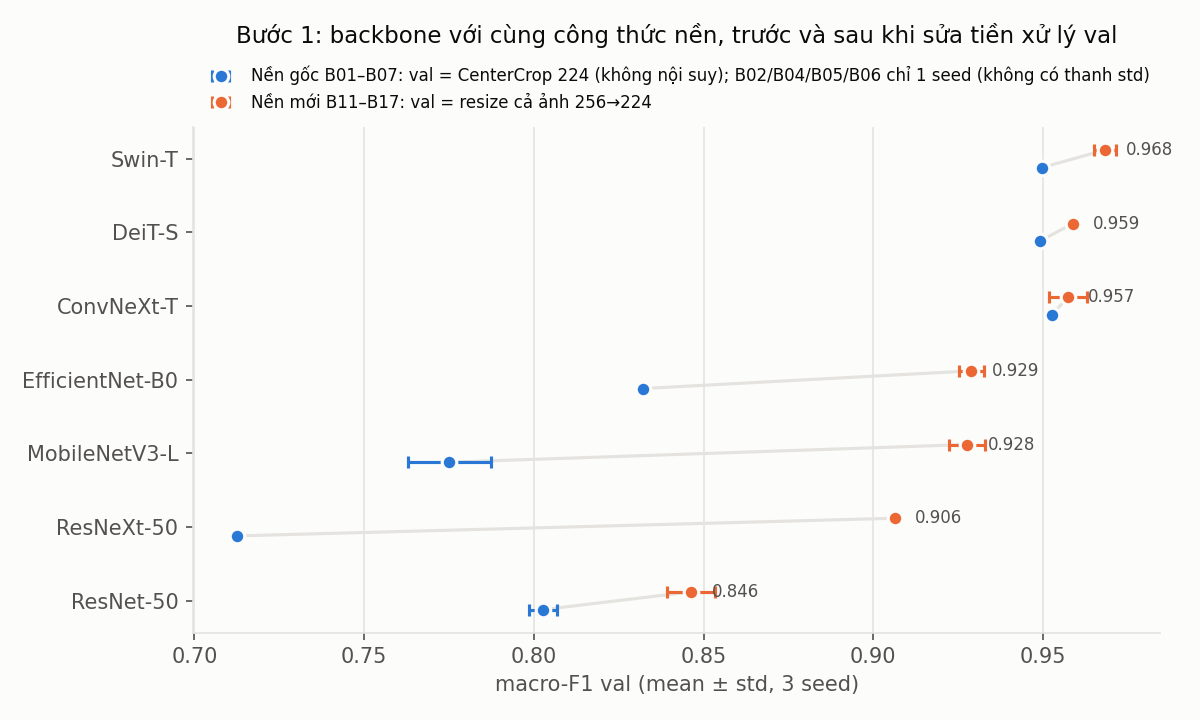

In [6]:
from train import Config, run
import run_exps as RX
if RUN_TRAINING:   # ví dụ: MobileNetV3-L với công thức nền đã sửa (giống B17), seed 0
    run(RX.make_config("B2", "B17", seed=0))

import make_results as MR
runs = MR.load_runs()
bb = MR.backbones_sheet(runs)
cols = ["exp_id", "backbone", "weight_tag", "params_M", "gmacs", "n_seeds", "macro_f1_val_mean",
        "macro_f1_val_std", "top1_val_mean", "train_s_per_epoch_mean", "latency_b1_p50_ms_mean", "gpu"]
display(bb[cols].round(4))
display(Image(SUB / "figures" / "fig_backbones.png", width=850))

## Bước 2: Công thức huấn luyện (≥ 3 trục)
Mỗi thí nghiệm khác mốc T00 của cùng backbone đúng một yếu tố; mỗi thí nghiệm chạy 3 seed. Cột `verdict` so Δ với std. Nhóm C là các tổ hợp kết hợp; X10–X12 là chưng cất tri thức.

,exp_id,diff_vs_baseline,baseline,seeds,macro_f1_val_mean,macro_f1_val_std,delta_macro_f1_vs_baseline,verdict
0,C01m,epochs=20; lr_backbone=0.0003; lr_head=0.003,T00m,"0,1,2",0.9543,0.0040,0.0273,tốt hơn (Δ > std)
1,C01s,epochs=20; img_size=288,T00s,"0,1,2",0.9757,0.0014,0.0073,tốt hơn (Δ > std)
2,C02m,aug='trivial'; epochs=20; lr_backbone=0.0003; lr_head=0.003,T00m,"0,1,2",0.9578,0.0035,0.0308,tốt hơn (Δ > std)
3,C02s,class_weight_beta=0.999; epochs=20; img_size=288; loss='...,T00s,"0,1,2",0.9760,0.0015,0.0077,tốt hơn (Δ > std)
4,C03m,aug='trivial'; epochs=20; img_size=288; lr_backbone=0.00...,T00m,"0,1,2",0.9642,0.0033,0.0372,tốt hơn (Δ > std)
5,C04m,aug='trivial'; class_weight_beta=0.999; epochs=20; loss=...,T00m,"0,1,2",0.9597,0.0028,0.0327,tốt hơn (Δ > std)
62,X10,teacher_run='C01s/seed0',C03m,"0,1,2",0.9686,0.0027,0.0043,tốt hơn (Δ > std)
63,X11,kd_alpha=0.9; teacher_run='C01s/seed0',C03m,"0,1,2",0.9701,0.0026,0.0058,tốt hơn (Δ > std)
64,X12,kd_temperature=1.0; teacher_run='C01s/seed0',C03m,"0,1,2",0.9671,0.0029,0.0029,không phân biệt được (|Δ| ≤ std)


Toàn bộ: 65 thí nghiệm, xem sheet Training của results.xlsx


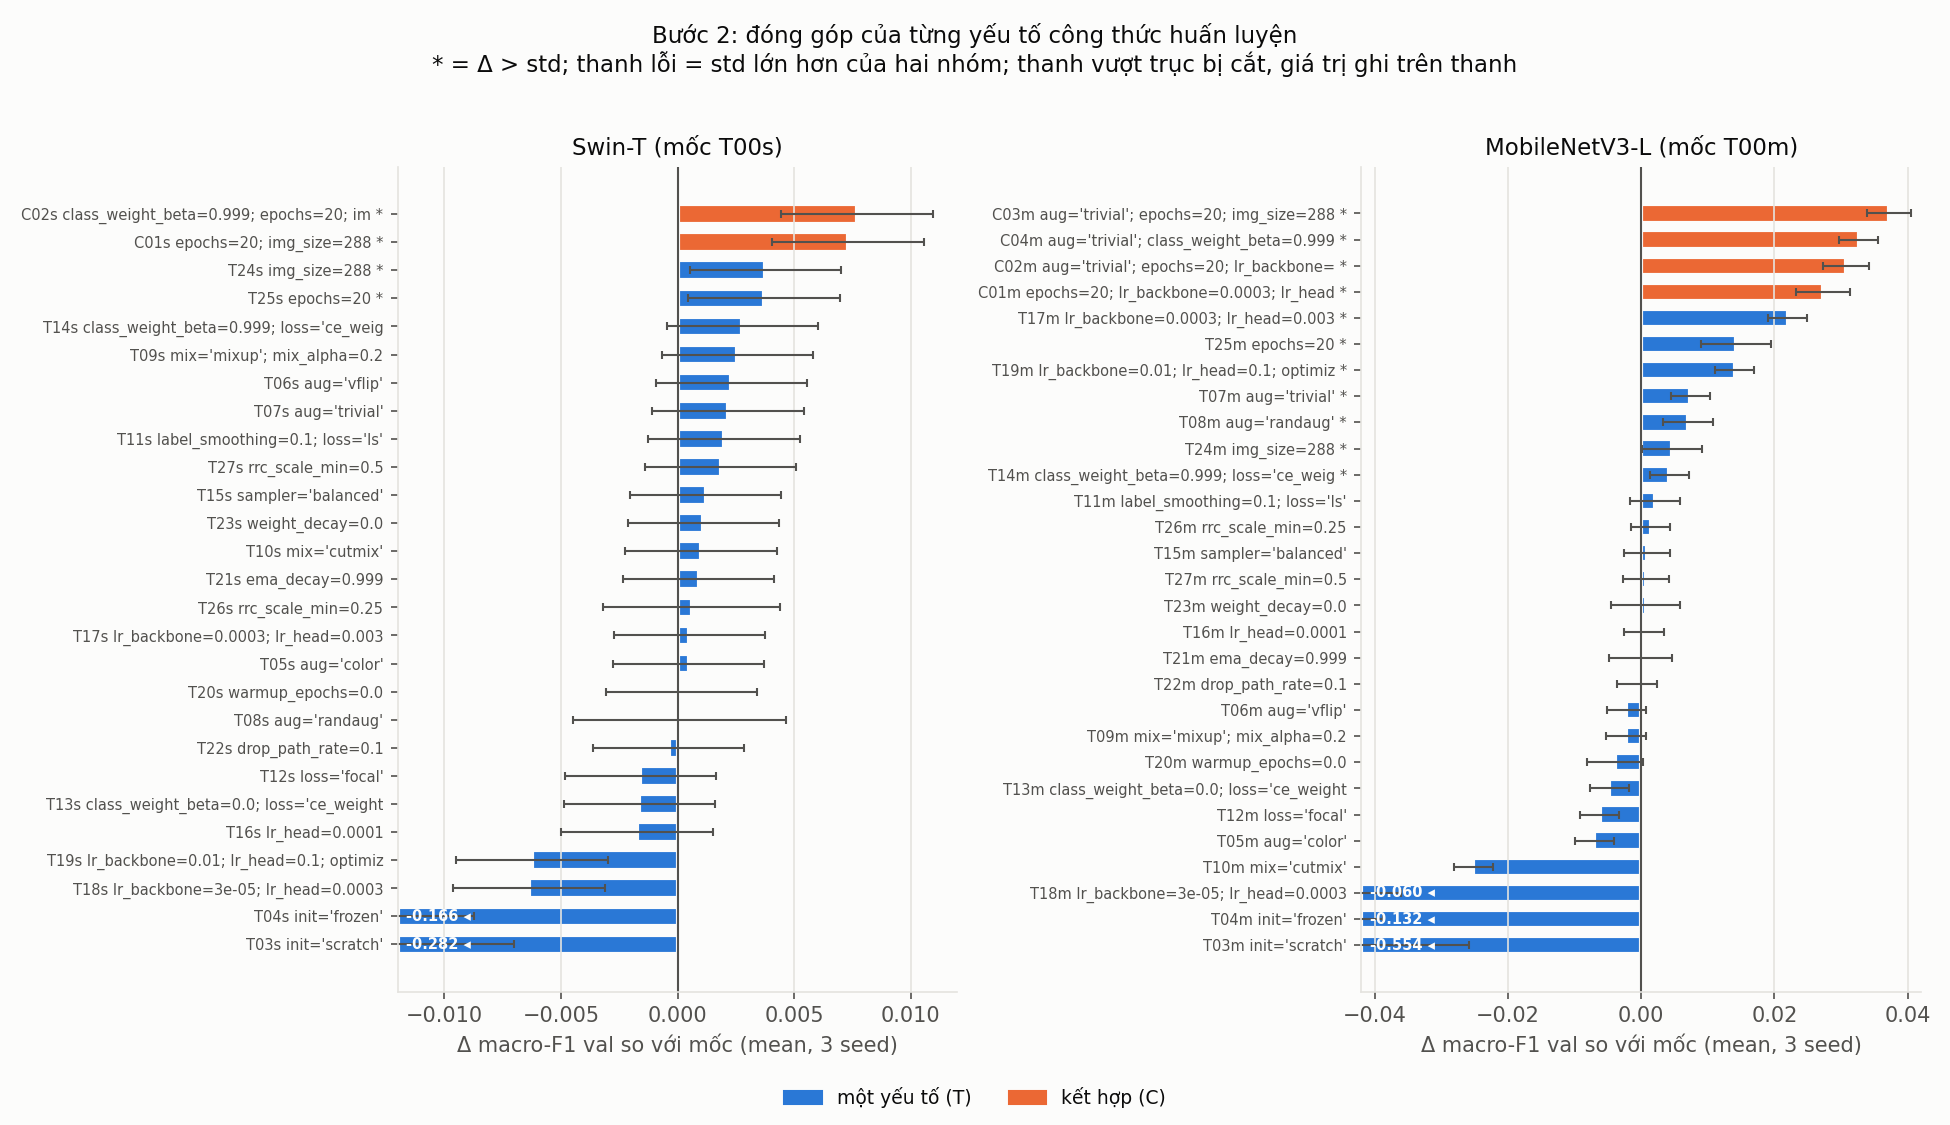

In [7]:
tr = MR.training_sheet(runs)
show = ["exp_id", "diff_vs_baseline", "baseline", "seeds", "macro_f1_val_mean", "macro_f1_val_std",
        "delta_macro_f1_vs_baseline", "verdict"]
display(tr[tr.exp_id.str.match(r"^(C|X1)")][show].round(4))
print("Toàn bộ:", len(tr), "thí nghiệm, xem sheet Training của results.xlsx")
display(Image(SUB / "figures" / "fig_ablation.png", width=950))

## Bước 3: Phương pháp suy luận (≥ 4) và độ trễ
- `run_inference.py` so mọi phương pháp trên 1 model và đo độ trễ: warmup 20 lần, `synchronize`, 100 lần đo, p50/p95/p99, TF32 tắt.
- `method_select.py` so các ứng viên trên 3 seed và chọn phương pháp cho chung kết, chỉ dùng val.

,exp_id,method,K,macro_f1_val,ece_val,p50_ms_b1,p95_ms_b1,images_per_s_b32,rel_cost_vs_I00,gpu
0,I00,1 view (resize cả ảnh 256 -> 224),1,0.9252,0.0104,1.8084,1.9618,9954.5868,1.0000,NVIDIA GeForce RTX 4090
1,I01,"TTA lật ngang, gộp xác suất",2,0.9249,0.0058,1.8494,2.0077,5025.8004,1.0227,NVIDIA GeForce RTX 4090
2,I01L,"TTA lật ngang, gộp logit (I03)",2,0.9251,0.0088,1.8494,2.0077,5025.8004,1.0227,NVIDIA GeForce RTX 4090
3,I02a,"5 crop 224 từ ảnh phóng 288, gộp xác suất",5,0.9410,0.0158,1.9390,2.0837,1666.4262,1.0722,NVIDIA GeForce RTX 4090
4,I02aL,"5 crop 224 từ ảnh phóng 288, gộp logit (I03)",5,0.9429,0.0051,1.9390,2.0837,1666.4262,1.0722,NVIDIA GeForce RTX 4090
5,I02b,"10 crop 224 (5 crop + lật) từ ảnh phóng 288, gộp xác suất",10,0.9455,0.0169,2.0556,2.1738,779.8922,1.1367,NVIDIA GeForce RTX 4090
6,I02bL,"10 crop 224 (5 crop + lật) từ ảnh phóng 288, gộp logit (...",10,0.9457,0.0061,2.0556,2.1738,779.8922,1.1367,NVIDIA GeForce RTX 4090
7,I02c,"3 tỉ lệ 224/288/320 (cả ảnh), gộp xác suất",3,0.9530,0.0142,5.5282,6.0626,2161.9260,3.0569,NVIDIA GeForce RTX 4090
8,I02cL,"3 tỉ lệ 224/288/320 (cả ảnh), gộp logit (I03)",3,0.9531,0.0050,5.5282,6.0626,2161.9260,3.0569,NVIDIA GeForce RTX 4090
9,I04_c224,độ phân giải kiểm tra 224 (Resize 256 + CenterCrop 224),1,0.7772,0.0206,1.8139,1.9685,9885.6370,1.0030,NVIDIA GeForce RTX 4090


**MS_C01s** (val, 3 seed, Δ theo cặp so với I00)

,method,n_seeds,macro_f1_val_mean,macro_f1_val_std,delta_vs_I00_mean,delta_vs_I00_std,ece_val_mean,ece_val_ts_mean,verdict
0,I00,3,0.9757,0.0014,0.0000,0.0000,0.0090,0.0031,mốc
1,I01L,3,0.9763,0.0019,0.0007,0.0007,0.0084,0.0040,không phân biệt được
2,I02aL,3,0.9777,0.0022,0.0020,0.0016,0.0090,0.0051,tốt hơn I00 (Δ > std)
3,I02bL,3,0.9785,0.0023,0.0029,0.0009,0.0086,0.0037,tốt hơn I00 (Δ > std)
4,I04_f320,3,0.9765,0.0016,0.0008,0.0015,0.0095,0.0046,không phân biệt được
5,I04_f352,3,0.9767,0.0008,0.0010,0.0009,0.0099,0.0041,tốt hơn I00 (Δ > std)
6,I04_c352,3,0.9772,0.0004,0.0015,0.0011,0.0089,0.0046,tốt hơn I00 (Δ > std)


**MS_C03m** (val, 3 seed, Δ theo cặp so với I00)

,method,n_seeds,macro_f1_val_mean,macro_f1_val_std,delta_vs_I00_mean,delta_vs_I00_std,ece_val_mean,ece_val_ts_mean,verdict
0,I00,3,0.9639,0.0030,0.0000,0.0000,0.0123,0.0061,mốc
1,I01L,3,0.9648,0.0042,0.0009,0.0012,0.0118,0.0054,không phân biệt được
2,I02aL,3,0.9726,0.0030,0.0087,0.0014,0.0082,0.0053,tốt hơn I00 (Δ > std)
3,I02bL,3,0.9724,0.0028,0.0085,0.0015,0.0080,0.0047,tốt hơn I00 (Δ > std)
4,I04_f320,3,0.9692,0.0032,0.0053,0.0002,0.0098,0.0052,tốt hơn I00 (Δ > std)
5,I04_f352,3,0.9702,0.0017,0.0064,0.0016,0.0088,0.0043,tốt hơn I00 (Δ > std)
6,I04_c352,3,0.9709,0.0020,0.0070,0.0012,0.0088,0.0051,tốt hơn I00 (Δ > std)


**MS_X11** (val, 3 seed, Δ theo cặp so với I00)

,method,n_seeds,macro_f1_val_mean,macro_f1_val_std,delta_vs_I00_mean,delta_vs_I00_std,ece_val_mean,ece_val_ts_mean,verdict
0,I00,3,0.9702,0.0023,0.0000,0.0000,0.0135,0.0061,mốc
1,I01L,3,0.9695,0.0024,-0.0007,0.0002,0.0128,0.0043,kém hơn I00
2,I02aL,3,0.9708,0.0007,0.0005,0.0019,0.0120,0.0039,không phân biệt được
3,I02bL,3,0.9717,0.0008,0.0015,0.0025,0.0109,0.0028,không phân biệt được
4,I04_f320,3,0.9715,0.0004,0.0012,0.0021,0.0111,0.0046,không phân biệt được
5,I04_f352,3,0.9725,0.0005,0.0022,0.0017,0.0125,0.0047,tốt hơn I00 (Δ > std)
6,I04_c352,3,0.9704,0.0007,0.0002,0.0029,0.0121,0.0059,không phân biệt được


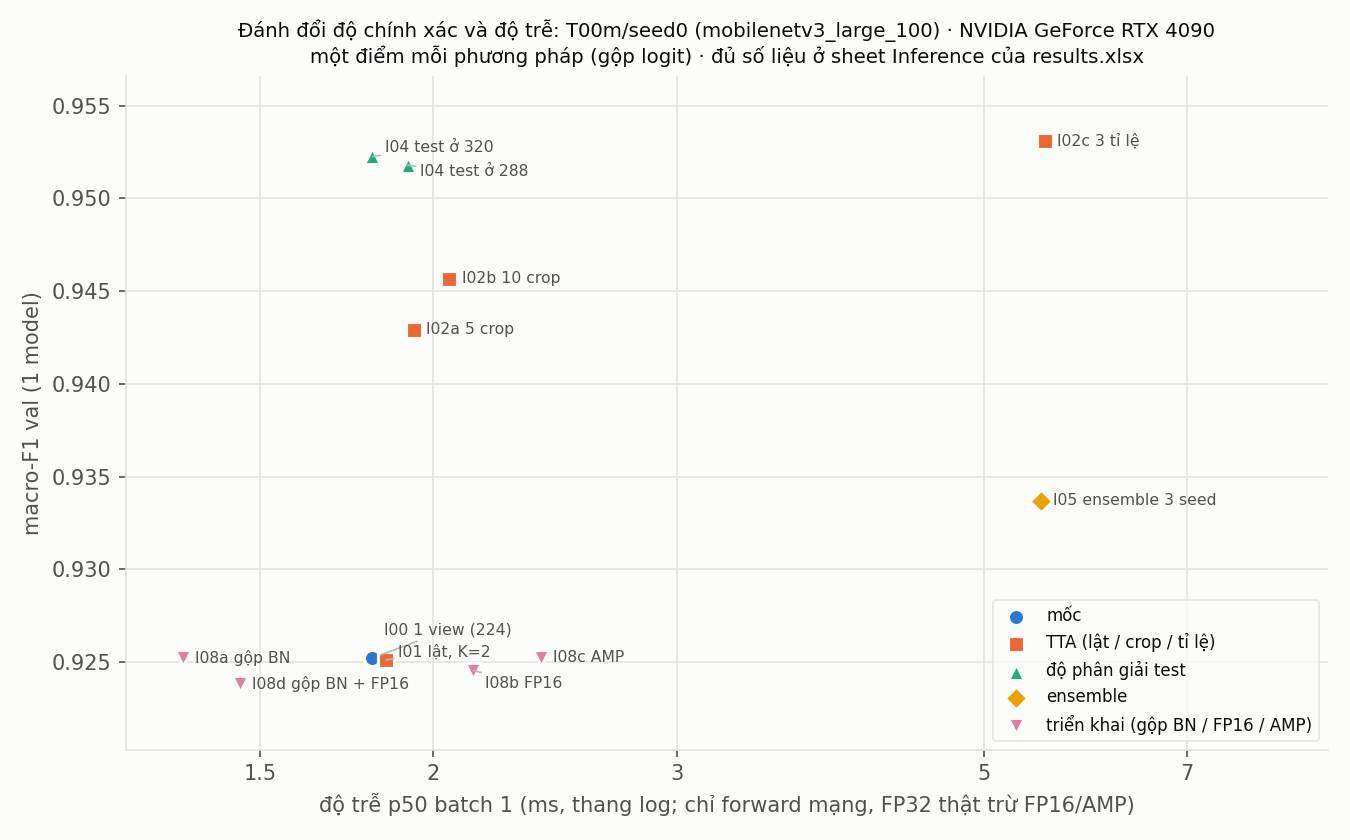

In [8]:
inf = pd.read_csv(REPO / "runs" / "inference" / "I_T00m" / "inference_val.csv")
display(inf[["exp_id", "method", "K", "macro_f1_val", "ece_val", "p50_ms_b1", "p95_ms_b1",
             "images_per_s_b32", "rel_cost_vs_I00", "gpu"]].round(4))
for tag in ("MS_C01s", "MS_C03m", "MS_X11"):
    display(Markdown(f"**{tag}** (val, 3 seed, Δ theo cặp so với I00)"))
    display(pd.read_csv(REPO / "runs" / "inference" / f"{tag}_summary.csv").round(4))
display(Image(SUB / "figures" / "I_T00m_tradeoff.png", width=750))

## Bước 4: Chung kết, ≥ 3 seed, test chạy một lần mỗi seed
Các lựa chọn đã chốt trên val:
- **F01:** Swin-T C01s + 10 crop + TS.
- **F02:** MobileNetV3 C03m + 5 crop + TS.
- **F03:** MobileNetV3 + KD + 1 view 352 + TS.
- **Mốc:** T00 (Swin) và T00m (MobileNetV3) với I00.

File dự đoán do `final_predict.py` ghi; file khoá `runs/final/` chặn mọi lần chạy test lại. Hai ô dưới chỉ **tính chỉ số** trên các file đó bằng `eval.py` của repo gốc.

In [9]:
P = SUB / "predictions"; L = LABELS_DIR
for tag in ("F01", "T00", "F03", "T00m"):
    out = subprocess.run([sys.executable, str(REPO / "eval.py"), "score", "--pred", str(P / f"{tag}_seed*_test.csv"),
                          "--test-csv", str(L / "test_subset0.csv"), "--labels", str(L / "labels.csv"),
                          "--tag", tag], capture_output=True, text=True)
    print(out.stdout.split("| Lớp |")[0])

### F01 (3 seed: [3, 4, 5]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9864 ± 0.0007 |
| macro-F1 | 0.9829 ± 0.0007 |
| balanced accuracy | 0.9826 ± 0.0005 |
| ECE (15 bin) | 0.0058 ± 0.0017 |
| NLL | 0.0453 ± 0.0018 |




### T00 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9776 ± 0.0007 |
| macro-F1 | 0.9701 ± 0.0008 |
| balanced accuracy | 0.9666 ± 0.0012 |
| ECE (15 bin) | 0.0100 ± 0.0012 |
| NLL | 0.0751 ± 0.0082 |




### F03 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9760 ± 0.0009 |
| macro-F1 | 0.9693 ± 0.0010 |
| balanced accuracy | 0.9665 ± 0.0031 |
| ECE (15 bin) | 0.0065 ± 0.0007 |
| NLL | 0.0699 ± 0.0039 |




### T00m (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9460 ± 0.0016 |
| macro-F1 | 0.9277 ± 0.0009 |
| balanced accuracy | 0.9173 ± 0.0026 |
| ECE (15 bin) | 0.0114 ± 0.0016 |
| NLL | 0.1702 ± 0.0055 |




In [10]:
# Tự chấm phần I của RUBRIC (eval.py grade) cho cấu hình chính F01 so với mốc T00.
# p95 = 4.35 ms: F03 (1 view 352, FP32, batch 1, RTX 3090), từ runs/inference/I_X11/latency.csv
out = subprocess.run([sys.executable, str(REPO / "eval.py"), "grade",
                      "--final", str(P / "F01_seed*_test.csv"), "--baseline", str(P / "T00_seed*_test.csv"),
                      "--uncal", str(P / "F01uncal_seed*_test.csv"), "--final-val", str(P / "F01_seed*_val.csv"),
                      "--test-csv", str(L / "test_subset0.csv"), "--val-csv", str(L / "val_subset0.csv"),
                      "--labels", str(L / "labels.csv"), "--latency-p95-ms", "4.35", "--latency-method", "proper"],
                     capture_output=True, text=True)
display(Markdown(out.stdout))

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 98.64% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 5 | 5 | final 0.9829, mốc 0.9701, Δ=+0.0128, s=0.0008 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 97.5% (mốc 88.5%), Snake Weed 95.4% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 0 | 1 | trước 0.0057, sau 0.0058 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9783, test 0.9829, chênh 0.0046 |
| I5 | Cấu hình thời gian thực | 2 | 2 | p95 = 4.3 ms (ngân sách 100 ms), đo đúng cách |

**Tổng các ý đã chấm: 19 / 20** (phần I tối đa 20).

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


## Bước 5: Sản phẩm
`make_results.py` ghi `results.xlsx` với đủ các sheet của GUIDE mục 6.1, cộng thêm sheet cho điểm thưởng. `make_figures.py` vẽ các biểu đồ tổng hợp. Ô dưới ghi lại hai thứ đó, rồi kiểm tra mỗi `exp_id` đều có ảnh trong `curves/`.

Đã ghi /vol/biomedic3/gn425/LabInAction/Lab02/submissions/2A202602747_NguyenSonGiang/results.xlsx


Đã ghi ['fig_ablation.png', 'fig_backbone_tradeoff.png', 'fig_backbones.png', 'fig_confusion_F01.png', 'fig_confusion_F03.png', 'fig_final_test.png']


{'Summary': 15, 'Backbones': 14, 'Training': 65, 'Inference': 132, 'Final': 20, 'PerClass': 45, 'Latency': 148, 'MethodSelect': 21, 'ONNX': 8, 'Robustness': 91}


,phần,exp_id,vai trò,mô tả,macro_f1_val,macro_f1_test,top1_test,ece_test,recall_chinee_test,recall_snake_test,GMAC,n_seeds
0,"A. chung kết vs mốc (test, 3 seed)",T00,mốc Swin-T,"Swin-T, công thức nền T00 + suy luận I00",0.9683 ± 0.0032,0.9701 ± 0.0008,0.9776 ± 0.0007,0.0100 ± 0.0012,0.9440 ± 0.0288,0.9183 ± 0.0057,NaN,NaN
1,"A. chung kết vs mốc (test, 3 seed)",F01,chung kết: tốt nhất (ngoại tuyến),"Swin-T C01s (res 288, 20 epoch) + 10 crop gộp logit + TS",0.9783 ± 0.0014,0.9829 ± 0.0007,0.9864 ± 0.0007,0.0058 ± 0.0017,0.9749 ± 0.0051,0.9542 ± 0.0028,NaN,NaN
2,"A. chung kết vs mốc (test, 3 seed)",T00m,mốc MobileNetV3,"MobileNetV3-L, công thức nền T00 + suy luận I00",0.9270 ± 0.0029,0.9277 ± 0.0009,0.9460 ± 0.0016,0.0114 ± 0.0016,0.8333 ± 0.0209,0.8529 ± 0.0294,NaN,NaN
3,"A. chung kết vs mốc (test, 3 seed)",F02,chung kết: mạng nhẹ,"MobileNetV3-L C03m (LR x3, 20 epoch, TrivialAugment, res...",0.9711 ± 0.0023,0.9730 ± 0.0017,0.9790 ± 0.0012,0.0061 ± 0.0018,0.9499 ± 0.0068,0.9330 ± 0.0198,NaN,NaN
4,"A. chung kết vs mốc (test, 3 seed)",F03,chung kết: thời gian thực,"MobileNetV3-L C03m + KD từ Swin (a 0.9, T 4) + 1 view 35...",0.9725 ± 0.0005,0.9693 ± 0.0010,0.9760 ± 0.0009,0.0065 ± 0.0007,0.9322 ± 0.0142,0.9444 ± 0.0057,NaN,NaN
5,"B. top 10 cấu hình huấn luyện (val, >= 3 seed)",C02s,swin_tiny_patch4_window7_224,swin_tiny_COMBO_res288_ep20_cb0.999,0.9760 ± 0.0015,NaN,NaN,NaN,NaN,NaN,8.647,3.0
6,"B. top 10 cấu hình huấn luyện (val, >= 3 seed)",C01s,swin_tiny_patch4_window7_224,swin_tiny_COMBO_res288_ep20,0.9757 ± 0.0014,NaN,NaN,NaN,NaN,NaN,8.647,3.0
7,"B. top 10 cấu hình huấn luyện (val, >= 3 seed)",T24s,swin_tiny_patch4_window7_224,swin_tiny_G_res288,0.9721 ± 0.0011,NaN,NaN,NaN,NaN,NaN,8.647,3.0
8,"B. top 10 cấu hình huấn luyện (val, >= 3 seed)",T25s,swin_tiny_patch4_window7_224,swin_tiny_G_20epochs,0.9720 ± 0.0024,NaN,NaN,NaN,NaN,NaN,4.490,3.0
9,"B. top 10 cấu hình huấn luyện (val, >= 3 seed)",T14s,swin_tiny_patch4_window7_224,swin_tiny_C_ce_classbalanced0.999,0.9711 ± 0.0020,NaN,NaN,NaN,NaN,NaN,4.490,3.0


86 exp_id, 86 có ảnh curves; thiếu: []


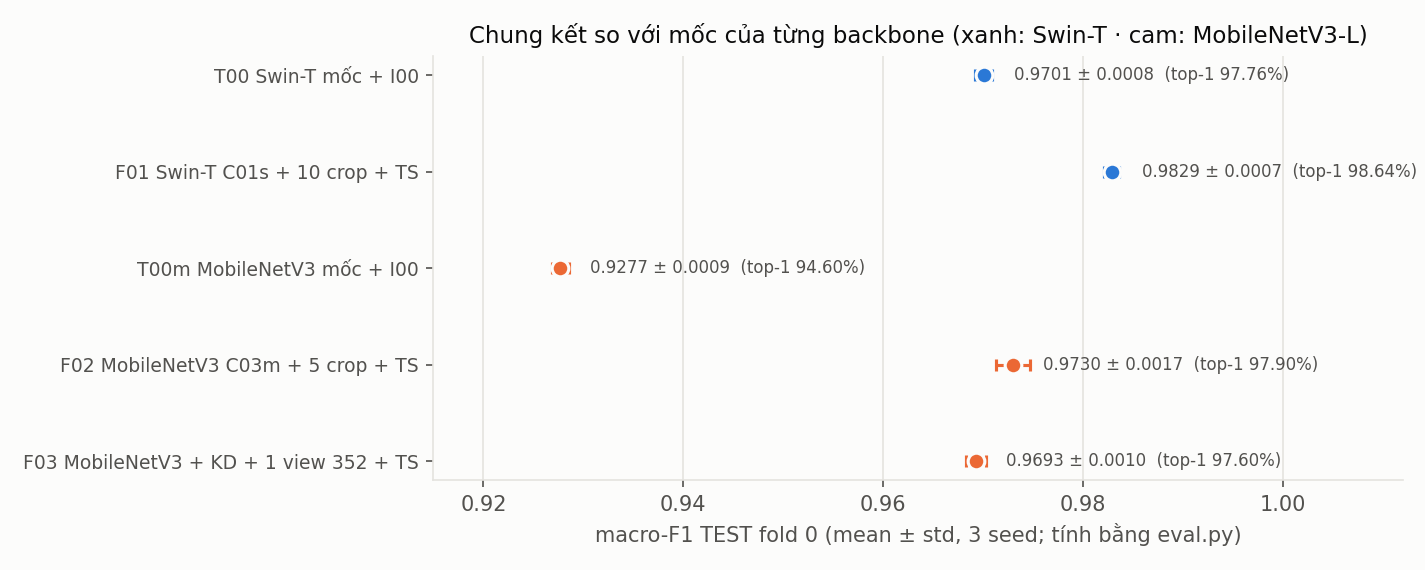

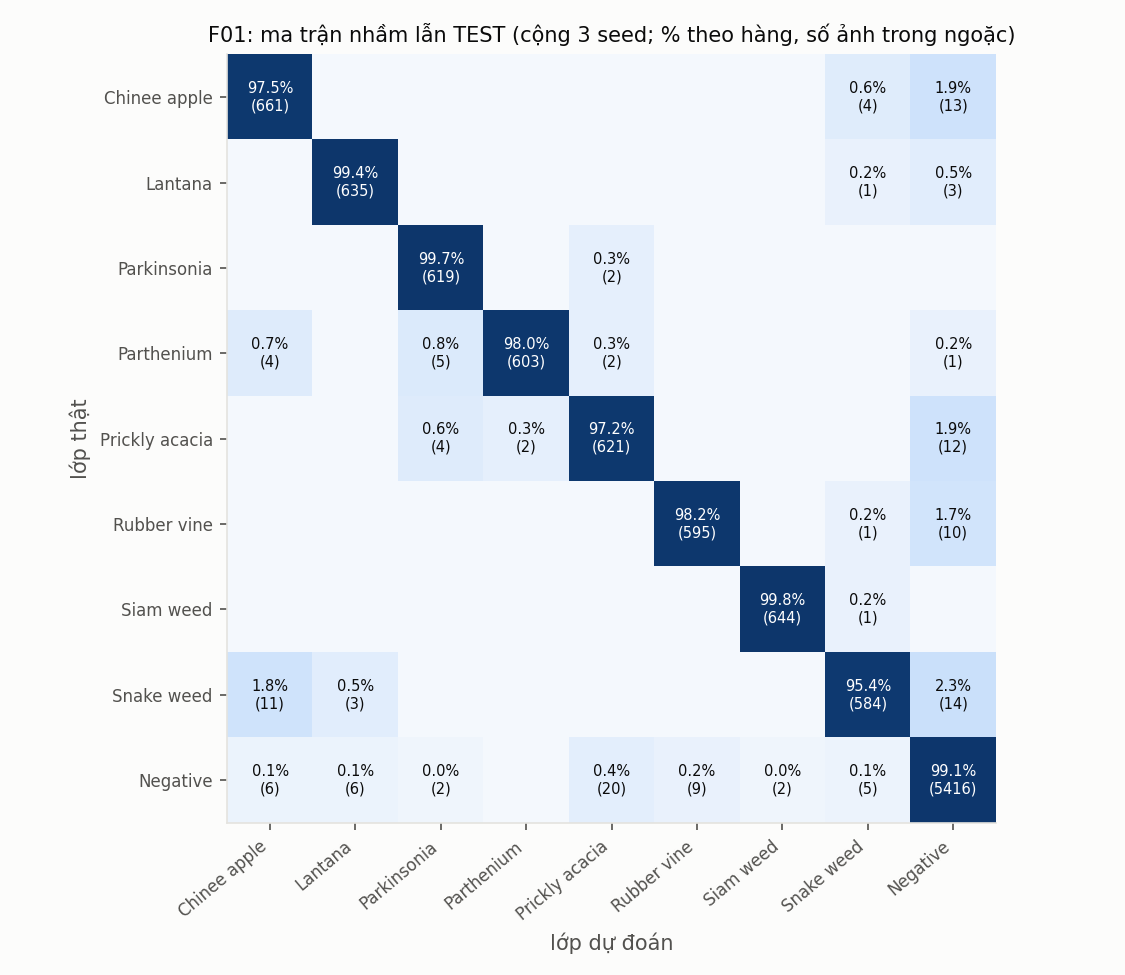

In [11]:
for script, args in (("make_results.py", ["--final", "F01", "F02", "F03", "--baseline", "T00", "T00m"]),
                     ("make_figures.py", [])):
    r = subprocess.run([sys.executable, script, *args], capture_output=True, text=True)
    print(r.stdout.strip().splitlines()[-1] if r.returncode == 0 else r.stderr[-2000:])
xl = pd.read_excel(SUB / "results.xlsx", sheet_name=None)
print({k: len(v) for k, v in xl.items()})
display(xl["Summary"])
curves = {p.name.split("_")[0] for p in (SUB / "curves").glob("*.png")}
missing = sorted(set(runs.exp_id) - curves)
print(f"{runs.exp_id.nunique()} exp_id, {len(curves)} có ảnh curves; thiếu: {missing}")
display(Image(SUB / "figures" / "fig_final_test.png", width=850))
display(Image(SUB / "figures" / "fig_confusion_F01.png", width=650))